這篇是用來操作我在看的課程所給的作業\
此篇為作業二－ 分類

教學網站&對應影片:\
http://speech.ee.ntu.edu.tw/~tlkagk/courses_ML20.html \
https://www.youtube.com/watch?v=fZAZUYEeIMg \
作業示範:\
https://colab.research.google.com/drive/1JaMKJU7hvnDoUfZjvUKzm9u-JLeX6B2C#scrollTo=OSL2CMEzmQvB

備註:\
建議將演算法流程簡單記錄下來\
這樣可以教好理解\
會有較好的學習效果\
在之後也可以快速地複習回憶.

問題整理:\
1.loss的意義是甚麼?為甚麼是用loss函式計算出的結果來更新演算法?\
2.試著去了解每個人寫完的東西\
了解他們為甚麼是這樣寫\
而其中的意義又是甚麼?\

# 導入需要用到的套件及個人測試用資料

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np

data_test=pd.util.testing.makeDataFrame()
data_test2=pd.util.testing.makeMixedDataFrame()
#____________________
data_test3=[[1,123,'xx',5678],
       [1,123,'xx',134],
       [1,123,'sx',562],
       [1,566,'sx',679],
       [1,566,'xx',6678],
       [2,123,'xx',5663],
       [2,123,'xx',6999],
       [2,123,'xx',12],
       [2,566,'sx',543],
       [2,566,'ym',562],
       [2,666,'ym',1355],
       [2,666,'tt',5685],
       [3,666,'sx',5522],
       [3,666,'tt',1345],
       [3,666,'xx',1357]]
data3_column=['type_id','no.','type','value']

data_test3=pd.DataFrame(data_test3,columns=data3_column)

#x=data_test3.values    x為array dataframe也可放入array
#y=pd.DataFrame(x,columns=data3_column)
#y

#________________________
#data_test4
#擁有空值的資料.
data_test4=pd.DataFrame(data_test3.values,columns=data3_column)
a=[0,3,6]

#下面這段可以試著簡化看看.
for n in a :
    data_test4.iloc[n,0]=None
a=[1,4,7]
for n in a :
    data_test4.iloc[n,1]=None
a=[2,5,8]
for n in a :
    data_test4.iloc[n,2]=None
a=[3,6,9]
for n in a :
    data_test4.iloc[n,3]=None
    
#修改後為以下
#a1=pd.array([0,3,6])
#a2=pd.array([0,1,2,3])
#
#for n2 in a2:
#    for n1 in a1:
#        data_test4.iloc[n1,n2]=None
#    a1=a1+1



data_test['A']=list(range(1,31))
data_test.B=sorted(list(range(-30,0)), reverse = True)


F:\MING\anaconda\lib\site-packages\pandas\util\__init__.py:8: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing


# 載入資料

In [3]:
X_test101=pd.read_csv('作業資料集/作業二/X_test')
X_train101=pd.read_csv('作業資料集/作業二/X_train')
Y_train101=pd.read_csv('作業資料集/作業二/Y_train')
#x3=pd.read_csv('作業資料集/作業二/test_no_label.csv')
#x4=pd.read_csv('作業資料集/作業二/train.csv')

In [4]:
#對比各資料差異

print(X_test101.shape)
print(X_train101.shape)
#print(Y_train.shape)
#print(x3.shape)
#print(x4.shape)


(27622, 511)
(54256, 511)


In [5]:
#測試1
#了解.strip()及.split()用法

x101='''
11111a,b,c,d,e,f,g11111
'''
x102='11111a,b,c,d,e,f,g11111'

#x102.strip('111').split(',')
#x101.strip('\n')

#_____________________________
#測試2
#測試with as及open()相關用法.

with open('作業資料集/作業二/X_train') as x101:
    x102=x101.read() #.read()輸出的值為str

#type(x101) #with as會輸出某種可迭代的資料.
#x101

# Logistic Regression

In [6]:
#對資料進行預處理.

# Parse csv files to numpy array
#str.strip(指定的字元):用於刪除字串頭尾指定的字元.
#str.split(指定的字母):用於分裂字串.以指定字母為分界點.
#這邊的f的型態應為某種可迭代的資料類型
#如此才可適用後面的語法.
with open('作業資料集/作業二/X_train') as f: 
    next(f)
    #line會分別帶入型態為str的f的值
    #透過下面代碼處理後
    #將變成較易使用的資料格式.
    X_train = np.array([line.strip('\n').split(',')[1:] for line in f], dtype = float)
with open('作業資料集/作業二/Y_train') as f:
    next(f)
    Y_train = np.array([line.strip('\n').split(',')[1] for line in f], dtype = float)
with open('作業資料集/作業二/X_test') as f:
    next(f)
    X_test = np.array([line.strip('\n').split(',')[1:] for line in f], dtype = float)

#這個函式會輸出:常規化後的資料、資料的平均值、資料的標準差.
#為甚麼這個函式在處理testdata時
#用到的平均值和標準差是traindata的?原因是甚麼?
#函式註解的寫法可以參考.
def _normalize(X, train = True, specified_column = None, X_mean = None, X_std = None): #建立一個常規化的函式.
    # This function normalizes specific columns of X.
    # The mean and standard variance of training data will be reused when processing testing data.
    #
    # Arguments:
    #     X: data to be processed
    #     train: 'True' when processing training data, 'False' for testing data
    #     specific_column: indexes of the columns that will be normalized. If 'None', all columns
    #         will be normalized.
    #     X_mean: mean value of training data, used when train = 'False'
    #     X_std: standard deviation of training data, used when train = 'False'
    # Outputs:
    #     X: normalized data
    #     X_mean: computed mean value of training data
    #     X_std: computed standard deviation of training data

    if specified_column == None:
        specified_column = np.arange(X.shape[1])
    if train:
        X_mean = np.mean(X[:, specified_column] ,0).reshape(1, -1)
        X_std  = np.std(X[:, specified_column], 0).reshape(1, -1)

    X[:,specified_column] = (X[:, specified_column] - X_mean) / (X_std + 1e-8)
     
    return X, X_mean, X_std

def _train_dev_split(X, Y, dev_ratio = 0.25): 
    # This function spilts data into training set and development set.
    train_size = int(len(X) * (1 - dev_ratio))
    return X[:train_size], Y[:train_size], X[train_size:], Y[train_size:]

# Normalize training and testing data
X_train, X_mean, X_std = _normalize(X_train, train = True)
X_test, _, _= _normalize(X_test, train = False, specified_column = None, X_mean = X_mean, X_std = X_std)
    
# Split data into training set and development set
dev_ratio = 0.1
X_train, Y_train, X_dev, Y_dev = _train_dev_split(X_train, Y_train, dev_ratio = dev_ratio)

train_size = X_train.shape[0]
dev_size = X_dev.shape[0]
test_size = X_test.shape[0]
data_dim = X_train.shape[1]
print('Size of training set: {}'.format(train_size))
print('Size of development set: {}'.format(dev_size))
print('Size of testing set: {}'.format(test_size))
print('Dimension of data: {}'.format(data_dim))

Size of training set: 48830
Size of development set: 5426
Size of testing set: 27622
Dimension of data: 510


In [7]:
x101=[[1,2,3,4,5],
     [1,2,3,4,5]]
len(x101)

2

In [8]:
#測試
#.shuffle()語法測試

x101=[[1],
     [2],
     [3],
     [4],
     [5],
     [6],
     [7],
     [8],
     [9],
     [10],
     [11],
     [12],
     [13],
     [14]]
y101=[[5],
     [5],
     [5],
     [5],
     [5],
     [5],
     [5],
     [5],
     [5],
     [5],
     [5],
     [5],
     [5],
     [5]]
x101=np.array(x101)
y101=np.array(y101)

randomize = np.arange(10)
np.random.shuffle(randomize)

x101[randomize]

array([[ 1],
       [10],
       [ 6],
       [ 2],
       [ 4],
       [ 7],
       [ 8],
       [ 5],
       [ 3],
       [ 9]])

In [9]:
#Some Useful Functions
#Some functions that will be repeatedly used when iteratively updating the parameters.
#這幾個函數可能會在訓練迴圈中被重複使用到。


def _shuffle(X, Y): #用於打亂資料的順序. #這個函式用意為何呢?
    # This function shuffles two equal-length list/array, X and Y, together.
    randomize = np.arange(len(X))  
    np.random.shuffle(randomize) #打亂順序. #.shuffle()用於打亂陣列中值得順序
    return (X[randomize], Y[randomize])

def _sigmoid(z):
    # Sigmoid function can be used to calculate probability.
    # To avoid overflow, minimum/maximum output value is set.
    return np.clip(1 / (1.0 + np.exp(-z)), 1e-8, 1 - (1e-8))

def _f(X, w, b):
    # This is the logistic regression function, parameterized by w and b
    #
    # Arguements:
    #     X: input data, shape = [batch_size, data_dimension]
    #     w: weight vector, shape = [data_dimension, ]
    #     b: bias, scalar
    # Output:
    #     predicted probability of each row of X being positively labeled, shape = [batch_size, ]
    return _sigmoid(np.matmul(X, w) + b)

def _predict(X, w, b): #用於四捨五入logistic regreesion function的結果,並把結果轉為int.  #把輸出結果轉換成0或1
    # This function returns a truth value prediction for each row of X 
    # by rounding the result of logistic regression function.
    return np.round(_f(X, w, b)).astype(np.int)
    
def _accuracy(Y_pred, Y_label): #用於計算準確度嗎?
    # This function calculates prediction
    acc = 1 - np.mean(np.abs(Y_pred - Y_label))
    return acc

In [10]:
#Functions about gradient and loss

def _cross_entropy_loss(y_pred, Y_label): #此函式即為數學中的驗證函式(驗證目標函式的好壞 痾...我不知道應該怎麼說)(類似loss function.)
    # This function computes the cross entropy.
    #
    # Arguements:
    #     y_pred: probabilistic predictions, float vector
    #     Y_label: ground truth labels, bool vector
    # Output:
    #     cross entropy, scalar
    cross_entropy = -np.dot(Y_label, np.log(y_pred)) - np.dot((1 - Y_label), np.log(1 - y_pred))
    return cross_entropy

def _gradient(X, Y_label, w, b): #這個函適用於計算出w和a需要更新的值
    # This function computes the gradient of cross entropy loss with respect to weight w and bias b.
    y_pred = _f(X, w, b)
    pred_error = Y_label - y_pred
    w_grad = -np.sum(pred_error * X.T, 1) #這邊比較不好理解.
    b_grad = -np.sum(pred_error)
    return w_grad, b_grad

In [23]:
# Zero initialization for weights ans bias
w = np.zeros((data_dim,)) 
b = np.zeros((1,))

# Some parameters for training    
max_iter = 10
batch_size = 8
learning_rate = 0.2

# Keep the loss and accuracy at every iteration for plotting
train_loss = []
dev_loss = []
train_acc = []
dev_acc = []

# Calcuate the number of parameter updates
step = 1

#為甚麼是這樣更新w和b?
#為甚麼需要資料洗牌?
#為甚麼要把資料分段計算gradient?
#除更號跑的次數式式之前學到的－...(忘記名字了)嗎?

# Iterative training
for epoch in range(max_iter):
    # Random shuffle at the begging of each epoch
    #(也許也可以試著不用批次的方式更新w和b,了解看看會有甚麼差異.)
    X_train, Y_train = _shuffle(X_train, Y_train)
        
    # Mini-batch training 
    for idx in range(int(np.floor(train_size / batch_size))):
        X = X_train[idx*batch_size:(idx+1)*batch_size]
        Y = Y_train[idx*batch_size:(idx+1)*batch_size]

        # Compute the gradient
        w_grad, b_grad = _gradient(X, Y, w, b)
            
        # gradient descent update
        # learning rate decay with time  ------>這應該是之前學到過的觀念,實際名字我有點忘記了,要去複習一下.
        w = w - learning_rate/np.sqrt(step) * w_grad
        b = b - learning_rate/np.sqrt(step) * b_grad

        step = step + 1
            
    # Compute loss and accuracy of training set and development set
    y_train_pred = _f(X_train, w, b)
    Y_train_pred = np.round(y_train_pred)
    train_acc.append(_accuracy(Y_train_pred, Y_train))
    train_loss.append(_cross_entropy_loss(y_train_pred, Y_train) / train_size)

    y_dev_pred = _f(X_dev, w, b)
    Y_dev_pred = np.round(y_dev_pred)
    dev_acc.append(_accuracy(Y_dev_pred, Y_dev))
    dev_loss.append(_cross_entropy_loss(y_dev_pred, Y_dev) / dev_size)

# print('Training loss: {}'.format(train_loss[-1]))
# print('Development loss: {}'.format(dev_loss[-1]))
# print('Training accuracy: {}'.format(train_acc[-1]))
# print('Development accuracy: {}'.format(dev_acc[-1]))

[1.00000000e-08 1.00000000e-08 5.00179310e-01 ... 1.09916546e-01
 6.55350405e-03 5.50045621e-02] [0. 0. 1. ... 0. 0. 0.]
[1.45044297e-01 6.23504065e-01 3.20252057e-08 ... 9.99932868e-01
 8.28435065e-01 6.24907127e-03] [0. 1. 0. ... 1. 1. 0.]
[1.60892979e-01 4.90775365e-01 8.20795691e-01 ... 3.32041141e-03
 6.36570957e-03 1.00000000e-08] [0. 0. 1. ... 0. 0. 0.]
[2.49500016e-03 1.71138464e-02 3.33263379e-04 ... 5.61000199e-04
 1.69695691e-04 1.00000000e-08] [0. 0. 0. ... 0. 0. 0.]
[1.85875117e-02 1.00000000e-08 4.16669992e-03 ... 9.82048266e-01
 3.66697747e-03 2.85710678e-08] [0. 0. 0. ... 1. 0. 0.]
[0.51304234 0.09496529 0.32273336 ... 0.18407649 0.23099873 0.01659476] [1. 0. 0. ... 0. 0. 0.]
[4.81524635e-01 3.76246533e-03 7.51792033e-01 ... 1.97142019e-02
 3.88815411e-02 1.00000000e-08] [0. 0. 1. ... 0. 0. 0.]
[0.01894326 0.17440361 0.06491872 ... 0.00971835 0.69866569 0.03678438] [0. 0. 0. ... 0. 1. 0.]
[7.13537242e-01 1.00000000e-08 3.22961333e-03 ... 8.04188146e-01
 1.00000000e-08 3

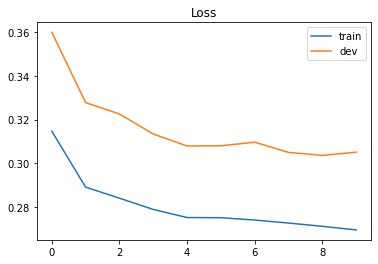

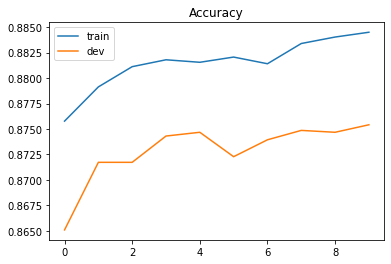

In [12]:
import matplotlib.pyplot as plt

# Loss curve
plt.plot(train_loss)
plt.plot(dev_loss)
plt.title('Loss')
plt.legend(['train', 'dev'])
plt.savefig('作業資料集/作業二/loss.png')
plt.show()

# Accuracy curve
plt.plot(train_acc)
plt.plot(dev_acc)
plt.title('Accuracy')
plt.legend(['train', 'dev'])
plt.savefig('作業資料集/作業二/acc.png')
plt.show()

In [13]:
# Predict testing labels
predictions = _predict(X_test, w, b)
with open('作業資料集/作業二/submit–logistic', 'w') as f:
    f.write('id,label\n')
    for i, label in  enumerate(predictions):
        f.write('{},{}\n'.format(i, label))

# Print out the most significant weights
ind = np.argsort(np.abs(w))[::-1] 
#這邊指定array的方式比較特別. 
#array和list指定元素方法為:my_list[start(開始的index):end(結束的index):sep(間隔)].
#而這邊的[::-1],-1的位置代標指定的間隔.
with open('作業資料集/作業二/X_test') as f:
    content = f.readline().strip('\n').split(',')
features = np.array(content)
for i in ind[0:10]:
    print(features[i], w[i])

 Trinadad&Tobago -2.4511364140827197
 Italy -1.5806070962601872
 ? -1.5669139900138573
 Other Rel <18 never marr not in subfamily -1.4872328616263024
 Unemployed full-time 1.1581229081422426
 ? -1.120046467985312
 Other Rel 18+ ever marr not in subfamily -1.025608878819747
 Child <18 spouse of subfamily RP -0.976871591824595
 1 0.8053210678633271
num persons worked for employer 0.781994985388954


# Porbabilistic generative model


理論上\
應該如何解釋porbabilistic generative model?

–透過各筆資料資料間分布的關係(關鍵字: covariance&mean)\
找出最適合群體的高斯分布方程式\
再運用不同群體的高絲分布方程式分別計算個別的機率並比較\
機率最高的那個群體便可將之分類到其群體.


–我必須先有個城市的架構\
才有辦法寫出我所想要的程式.

In [14]:
#資料預處理.

# Parse csv files to numpy array
with open('作業資料集/作業二/X_train') as f: 
    next(f)
    X_train = np.array([line.strip('\n').split(',')[1:] for line in f], dtype = float)
with open('作業資料集/作業二/Y_train') as f:
    next(f)
    Y_train = np.array([line.strip('\n').split(',')[1] for line in f], dtype = float)
with open('作業資料集/作業二/X_test') as f:
    next(f)
    X_test = np.array([line.strip('\n').split(',')[1:] for line in f], dtype = float)

# Normalize training and testing data
X_train, X_mean, X_std = _normalize(X_train, train = True)
X_test, _, _= _normalize(X_test, train = False, specified_column = None, X_mean = X_mean, X_std = X_std)

In [15]:
#測試
#測試for in及if寫在宣告裡的方法.

x101=(1,2,3,4,5,6,7,8,9)
y101=(1,0,1,0,1,0,1,0,1)
x102=np.array([x for x,y in zip(x101,y101) if y==0])
x102

array([2, 4, 6, 8])

In [16]:
# Compute in-class mean
X_train_0 = np.array([x for x, y in zip(X_train, Y_train) if y == 0]) #這段及下一段的寫法有點陌生.
X_train_1 = np.array([x for x, y in zip(X_train, Y_train) if y == 1])

mean_0 = np.mean(X_train_0, axis = 0)
mean_1 = np.mean(X_train_1, axis = 0)  

# Compute in-class covariance
cov_0 = np.zeros((data_dim, data_dim))
cov_1 = np.zeros((data_dim, data_dim))
# 問題:
# –這兩段for in的用意是甚麼?
# –會甚麼civariance得是510*510的矩陣?
# –transpose後在相乘會怎麼運算?
# 這些問題可能跟.dot()的運算方式有關聯,因此才必須把程式碼設計成下面那樣.
# 這邊幾個問題的理解需要先了解一些基本條件
# 詳細說明放在下個cell.
# –下面np.dot()那邊,是甚麼乘甚麼?甚麼矩陣乘甚麼矩陣?會是如何運算?
# 下面相乘的兩個分別為(510,1)和(1,510)
# 結果會為算出一個(510,510)矩陣
# 為甚麼下面是用np.dot()–內積?
# 就我目前的理解
# 似乎可以這樣認為.
for x in X_train_0:
    cov_0 += np.dot(np.transpose([x - mean_0]), [x - mean_0]) / X_train_0.shape[0] #這邊式子的運算順序要注意.
for x in X_train_1:
    cov_1 += np.dot(np.transpose([x - mean_1]), [x - mean_1]) / X_train_1.shape[0]

# Shared covariance is taken as a weighted average of individual in-class covariance.
cov = (cov_0 * X_train_0.shape[0] + cov_1 * X_train_1.shape[0]) / (X_train_0.shape[0] + X_train_1.shape[0])

In [17]:
#概念建立.
# –array和list可看作類似的東西. 
# EX:[array([1,2,3,4,5])]和[[1,2,3,4,5]]會視作相同的矩陣
# 若使用np.transpose()處理這兩個東西
# 會得到相同的矩陣、相同的結果.

#問題:x53和x55呈上同樣的數字結果是否會相同?
#會是相同
#只是x55為list
#不能直接進行運算
#要先把list轉為array
#或是利用np.dot()可以直接運算.


In [18]:
#測試
#了解np.dot()中的參數及其結果為甚麼樣的矩陣.

x101=np.dot(np.transpose([X_train_0[0] - mean_0]), [X_train_0[0]- mean_0]) / X_train_0.shape[0]
#print([X_train_0[0]-mean_0])#下面的型態與這個的型態不同.
print((X_train_0[0]-mean_0).shape)
print((np.transpose([X_train_0[0] - mean_0])).shape) #有無transpose有差別.
print(np.dot(np.transpose([X_train_0[0] - mean_0]), [X_train_0[0]- mean_0]).shape)#為甚麼會變成510*510的矩陣? 這是矩陣的運算方式


(510,)
(510, 1)
(510, 510)


In [19]:
#np.dot()參考

# 函示np.dot()瞞容易搞混的.
# np.dot()可能需要了解矩陣乘法的運算方式才比較能了解實際如何運算的–
# https://zh.wikipedia.org/wiki/%E7%9F%A9%E9%99%A3%E4%B9%98%E6%B3%95 .
# 重要概念:
# 若A為m*n矩陣,B為n*p矩陣
# 則他們的乘積A．B會是一個m*p矩陣
# n要相同才能進行乘積.
# 套用這個概念便好的去理解下面的各種運算.

# 所以np.dot()array或list參數能否進行運算
# 取決於兩參數筆數是否吻合嗎? EX:(5,1)和(5,10).
# np.dot()第二個參數代表被乘數?

x51=np.array([1,2,3,4,5])
x52=np.array([[1],[2],[3],[4],[5]])
x53=np.array([[1,1,1,1,1],
             [2,2,2,2,2],
             [3,3,3,3,3],
             [4,4,4,4,4],
             [5,5,5,5,5]])
x54=np.array([[1,2,3,4,5],
            [1,2,3,4,5],
            [1,2,3,4,5],
            [1,2,3,4,5],
            [1,2,3,4,5]])
x55=[[1,1,1,1,1],
     [2,2,2,2,2],
     [3,3,3,3,3],
     [4,4,4,4,4],
     [5,5,5,5,5]]
w51=np.array([1,2,3,4,5])
w52=np.array([[1],[2],[3],[4],[5]])
w53=np.array([10])
w54=10
w55=[np.array([1,2,3,4,5])]

 
#兩個array五個數相乘對應位置的數字,再把五個結果加總.輸出結果為int
print(np.dot(x51,w51)) 

print('_________')
#兩個array五個數相乘對應位置的數字,因為w52為list的關係,五個數字相乘的值都為list,再把list中的值加總.最後的輸出為list.
#更新:
print(x51)
print(w52)
print('x51*w52 :') 
print(np.dot(x51,w52))
print('w52*[x51] :')
print(np.dot(w52,[x51]))

print('_______')
#同np.dot(x54,w52)
print('x53*w52 :')
print(np.dot(x53,w52))
#x54的5個list分別乘上w52,list中5對應的數字相乘,再將相乘的結果相加.
print('x54*w52 :') 
print(np.dot(x54,w52))

print('__________') #區隔線
print('x51*w54 :') 
print(np.dot(x51,w54))
#x52的5個數值分別乘上w53的那一個數值.最後輸出為包含五個數值的list.
print('x52*w53 :') 
print(np.dot(x52,w53))
print('x52*w54 :') 
print(np.dot(x52,w54))

print('x54*w51 :')
print(np.dot(x54,w51))

print('__________________')
print('x52*w55 :') 
print(np.dot(x52,w55)) #參數前後向顛倒結果便會不同.

55
_________
[1 2 3 4 5]
[[1]
 [2]
 [3]
 [4]
 [5]]
x51*w52 :
[55]
w52*[x51] :
[[ 1  2  3  4  5]
 [ 2  4  6  8 10]
 [ 3  6  9 12 15]
 [ 4  8 12 16 20]
 [ 5 10 15 20 25]]
_______
x53*w52 :
[[15]
 [30]
 [45]
 [60]
 [75]]
x54*w52 :
[[55]
 [55]
 [55]
 [55]
 [55]]
__________
x51*w54 :
[10 20 30 40 50]
x52*w53 :
[10 20 30 40 50]
x52*w54 :
[[10]
 [20]
 [30]
 [40]
 [50]]
x54*w51 :
[55 55 55 55 55]
__________________
x52*w55 :
[[ 1  2  3  4  5]
 [ 2  4  6  8 10]
 [ 3  6  9 12 15]
 [ 4  8 12 16 20]
 [ 5 10 15 20 25]]


In [20]:
# 關於SVD的部分
# 這部分是蠻有難度的
# 我暫時也不確定之後會不會再碰到相關的東西
# 因次就先不去做深入的了解
# 此處我只會簡單得提及目前的了解.
# 此段代碼會帶入cov(前面計算出的covariance matrix)以計算出"廣義逆陣"(應該是這個名字)
# 之後會再以廣義逆陣取代原本的covariance matrix去之後的計算.
# 奇異值是甚麼?我應該怎麼理解?
# Compute inverse of covariance matrix.
# Since covariance matrix may be nearly singular, np.linalg.inv() may give a large numerical error.
# Via SVD decomposition, one can get matrix inverse efficiently and accurately.
u, s, v = np.linalg.svd(cov, full_matrices=False)
inv = np.matmul(v.T * 1 / s, u.T)

# Directly compute weights and bias
w = np.dot(inv, mean_0 - mean_1)
b =  (-0.5) * np.dot(mean_0, np.dot(inv, mean_0)) + 0.5 * np.dot(mean_1, np.dot(inv, mean_1))\
    + np.log(float(X_train_0.shape[0]) / X_train_1.shape[0]) 

# Compute accuracy on training set.
# 我們建立的方程式目的是計算資料為某分類的機率
# 計算出的值大於0.5則為屬於此分類
# 小於0.5則為不屬於此分類
# 換句話說 計算出的東西僅代表是或否
# 並不代表實際上的分類名稱.
# 此處為計算資料(我忘記到底是處理甚麼資料了)為Y=0的機率
# 需要將1和0也就是是或否
# 轉化成對應的分類
# 因此才會出現這段第一行的運算.
Y_train_pred = 1 - _predict(X_train, w, b)#這邊有需要理解清楚.
print('Training accuracy: {}'.format(_accuracy(Y_train_pred, Y_train)))

Training accuracy: 0.8731753170156296


In [21]:
#測試
# 嘗試不經過上面的奇異值分解處理
# 直接用計算出的covariance繼續後續的步驟.
# 結果不理想
# 準確度降低很多.
# 原因為何?

# Directly compute weights and bias
w = np.dot(cov, mean_0 - mean_1)
b =  (-0.5) * np.dot(mean_0, np.dot(cov, mean_0)) + 0.5 * np.dot(mean_1, np.dot(cov, mean_1))\
    + np.log(float(X_train_0.shape[0]) / X_train_1.shape[0]) 

# Compute accuracy on training set
Y_train_pred = 1 - _predict(X_train, w, b)
print('Training accuracy: {}'.format(_accuracy(Y_train_pred, Y_train)))

Training accuracy: 0.6143099380713654


In [22]:
# Predict testing labels
predictions = 1 - _predict(X_test, w, b)
with open('作業資料集/作業二/submit–generative', 'w') as f:
    f.write('id,label\n')
    for i, label in  enumerate(predictions):
        f.write('{},{}\n'.format(i, label))

# Print out the most significant weights
ind = np.argsort(np.abs(w))[::-1]
with open('作業資料集/作業二/X_test') as f:
    content = f.readline().strip('\n').split(',')
features = np.array(content)
for i in ind[0:10]:
    print(features[i], w[i])

 Sales 6.905526906598062
 3 6.905526906598062
 3 6.905526906598062
 Utilities and sanitary services 6.905526906598062
 1 -6.847618473488425
 Self-employed-not incorporated 6.8382430896958795
dividends from stocks 6.430991574998803
num persons worked for employer -5.893737079560322
 Child under 18 ever married 5.442058231884009
 Grandchild 18+ never marr RP of subfamily 5.431532940935027


閱讀完!!!!